In [9]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [10]:
# Carga documento

df_hr_limpio = pd.read_csv('../df_hr_limpio.csv')

In [11]:
# cuanta gente se ha ido de la empresa 

# Conteo general de attrition y %
print(df_hr_limpio['attrition'].value_counts())
print("---" * 100)
print(df_hr_limpio['attrition'].value_counts(normalize=True) * 100)

attrition
No     1233
Yes     237
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


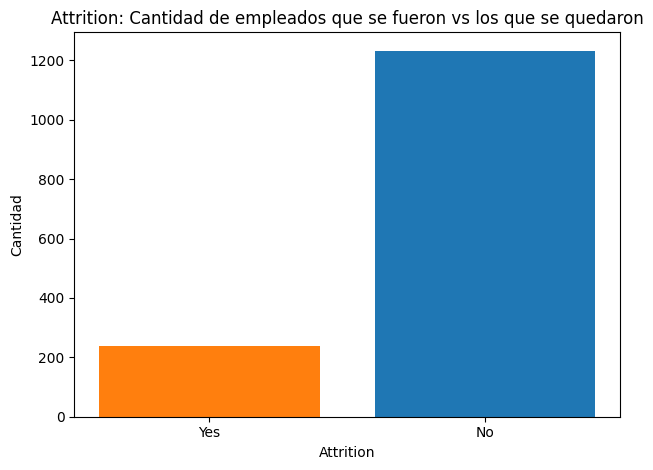

In [12]:
import matplotlib.pyplot as plt

plt.figure()

# Obtener datos
counts = df_hr_limpio['attrition'].value_counts()

# Ordenar y controlar colores
x = ['Yes', 'No']
y = [counts['Yes'], counts['No']]

# Asignar colores según tu solicitud
plt.bar(x, y, color=['tab:orange', 'tab:blue'])

plt.title('Attrition: Cantidad de empleados que se fueron vs los que se quedaron')
plt.xlabel('Attrition')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

Segun la IA, en análisis profesional se manejan estos rangos:


Bajo	0–10%	Plantilla estable, buen clima, buena retención
Moderado	10–15%	Normal en muchos sectores. Vigilancia ligera
Alto	15–20%	Ya indica posibles problemas internos
Crítico	>20%	Rotación peligrosa, impacto fuerte en costes y productividad

** nuestro resultado está dentro del rango moderado, pero no llega a sr crítico. Merece analizarse y detectar causas para prevención.

In [13]:
# la edad que tienen
# Edad por attrition
edad_attrition = df_hr_limpio.groupby('attrition')['age'].describe()
edad_attrition

,count,mean,std,min,25%,50%,75%,max
attrition,,,,,,,,
No,1233.0,37.482563,8.650214,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.843882,9.373426,18.0,28.0,32.0,39.0,58.0


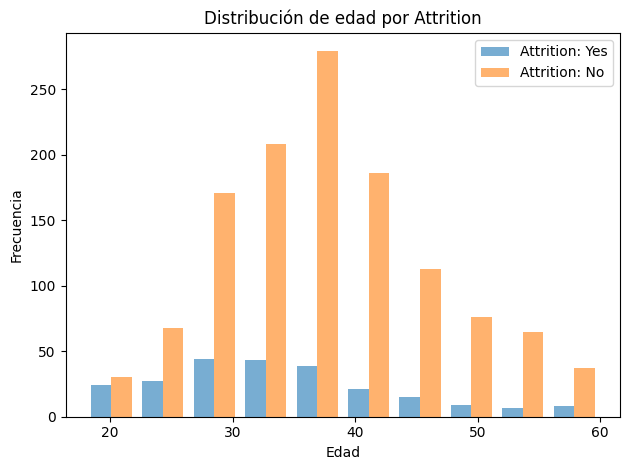

In [14]:
plt.figure()

data_yes = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']['age']
data_no  =df_hr_limpio[df_hr_limpio['attrition'] == 'No']['age']

plt.hist([data_yes, data_no], 
         label=['Attrition: Yes', 'Attrition: No'],
         alpha=0.6)

plt.title('Distribución de edad por Attrition')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

- la gente que se va es más joven que la media (37 años media trabajadores vs 33 años media gente que se va)

- El std (desviación estándar) es más alta en los que se van:

No → 8.65
Yes → 9.37

Esto indica que la rotación está menos concentrada en un solo grupo de edad, pero aun así hay un sesgo claro hacia las edades más bajas.
En todos quantiles, los que se van son 3–4 años más jóvenes.




In [15]:
# si han tenido aumentos de sueldo

# Aumentos de sueldo por attrition
aumentos = df_hr_limpio.groupby('attrition')['percent_salary_hike'].describe()
aumentos

,count,mean,std,min,25%,50%,75%,max
attrition,,,,,,,,
No,1233.0,15.231144,3.639511,11.0,12.0,14.0,18.0,25.0
Yes,237.0,15.097046,3.770294,11.0,12.0,14.0,17.0,25.0


El aumento de sueldo no parece influir en el hecho de que la gente se vaya.

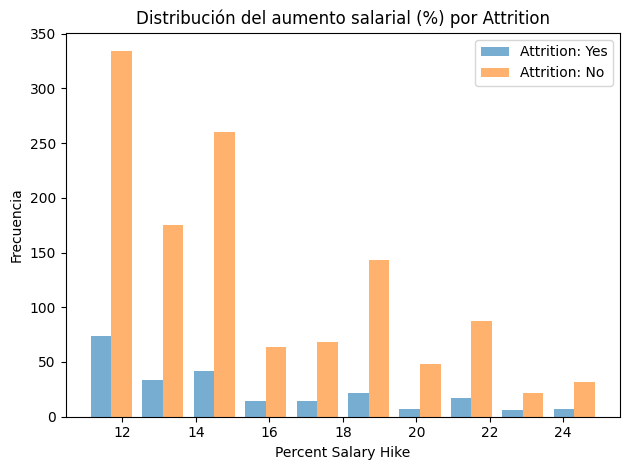

In [16]:
plt.figure()

data_yes = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']['percent_salary_hike']
data_no  = df_hr_limpio[df_hr_limpio['attrition'] == 'No']['percent_salary_hike']

plt.hist([data_yes, data_no], 
         label=['Attrition: Yes', 'Attrition: No'],
         alpha=0.6)

plt.title('Distribución del aumento salarial (%) por Attrition')
plt.xlabel('Percent Salary Hike')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# si hacen horas extra

# Horas extra por attrition
horas_extra = df_hr_limpio.groupby(['attrition', 'over_time']).size().unstack().fillna(0).reset_index()
horas_extra


over_time,attrition,No,Yes
0,No,953,280
1,Yes,112,125
